In [1]:
# ---------------------------------------------------------
# Completeness evaluation setup
# ---------------------------------------------------------
# Completeness measures:
#
# "How much of the clinically important information from
# the original patient record is captured by the generated
# summary?"
#
# Evaluation direction:
#
# Original record -> reference checklist -> generated summary
#
# The reference checklist is created ONCE per patient and
# reused across all four summarization workflows.

import pandas as pd
import json
from pathlib import Path

In [2]:
# ---------------------------------------------------------
# Project paths
# ---------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent.parent

RESULTS_DIR = PROJECT_ROOT / "data" / "results"

EVALUATION_DIR = RESULTS_DIR / "evaluation"

EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
# Files that will eventually store completeness outputs.
CHECKLIST_PATH = (
    EVALUATION_DIR / "completeness_reference_checklists.json"
)

COMPLETENESS_RESULTS_PATH = (
    EVALUATION_DIR / "completeness_results.json"
)


print("Project root:", PROJECT_ROOT)
print("Evaluation directory:", EVALUATION_DIR)
print("Checklist output:", CHECKLIST_PATH)

Project root: /Users/pallavi_chandanshive/projects/clinical-summarization-eval
Evaluation directory: /Users/pallavi_chandanshive/projects/clinical-summarization-eval/data/results/evaluation
Checklist output: /Users/pallavi_chandanshive/projects/clinical-summarization-eval/data/results/evaluation/completeness_reference_checklists.json


In [4]:
# ---------------------------------------------------------
# Load and reconstruct the frozen source clinical records
# ---------------------------------------------------------
# We use the exact preprocessing decisions from the four
# summarization workflows:
#
# 1. Remove invalid "#NAME?" notes.
# 2. Sort notes chronologically.
# 3. Remove duplicate note text within each patient.
#
# These deduplicated notes form the source of truth from
# which the completeness reference checklist will be built.

CLINICAL_NOTES_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "clinical_notes.csv"
)

notes = pd.read_csv(CLINICAL_NOTES_PATH)


# Remove invalid notes.
notes_clean = notes[
    notes["clean_note_text"]
    .astype(str)
    .str.strip() != "#NAME?"
].copy()


In [6]:
# Apply the same frozen deduplication used in the study.
notes_dedup = (
    notes_clean
    .sort_values([
        "person_id",
        "creation_timestamp"
    ])
    .drop_duplicates(
        subset=[
            "person_id",
            "clean_note_text"
        ],
        keep="first"
    )
    .reset_index(drop=True)
)

In [7]:
# ---------------------------------------------------------
# Reconstruct complete longitudinal records
# ---------------------------------------------------------

patient_source_documents = (
    notes_dedup
    .groupby("person_id", sort=False)["clean_note_text"]
    .apply(
        lambda texts: "\n\n".join(
            texts.astype(str)
        )
    )
    .to_dict()
)

In [8]:
# ---------------------------------------------------------
# Validate frozen source corpus
# ---------------------------------------------------------

print("Original notes:", len(notes))
print("After #NAME? removal:", len(notes_clean))
print("After deduplication:", len(notes_dedup))
print("Patients:", len(patient_source_documents))

Original notes: 1602
After #NAME? removal: 1595
After deduplication: 1103
Patients: 50


In [10]:
# ---------------------------------------------------------
# Load and validate the frozen study cohort
# ---------------------------------------------------------
# Completeness must evaluate the exact same 50 patients
# used by all four summarization workflows.

STUDY_PATIENT_IDS_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "patients"
    / "study_patient_ids.json"
)


with open(STUDY_PATIENT_IDS_PATH, "r") as f:
    study_patient_ids = json.load(f)


# Convert to sets only for validation.
study_patient_id_set = set(study_patient_ids)
source_patient_id_set = set(patient_source_documents.keys())


print("Study patients:", len(study_patient_ids))
print("Source patients:", len(patient_source_documents))

print(
    "Patient IDs match:",
    study_patient_id_set == source_patient_id_set
)

print(
    "Missing source records:",
    study_patient_id_set - source_patient_id_set
)

print(
    "Extra source records:",
    source_patient_id_set - study_patient_id_set
)

Study patients: 50
Source patients: 50
Patient IDs match: True
Missing source records: set()
Extra source records: set()


In [21]:
# ---------------------------------------------------------
# Reference checklist extraction prompt
# ---------------------------------------------------------
# The checklist represents clinically important information
# from the complete longitudinal source record.
#
# It is created from SOURCE NOTES ONLY. Generated summaries
# are never shown during checklist creation, preventing the
# four workflows from influencing the reference standard.

CHECKLIST_SYSTEM_PROMPT = """
You are evaluating longitudinal clinical summaries.

Your task is to identify the clinically important information from a
patient's longitudinal clinical record that a high-quality clinical
summary should reasonably preserve.

Use only information explicitly supported by the provided clinical record.

Do not attempt to reproduce every detail in the notes. 

Include a checklist item only if omitting that information would
meaningfully reduce the clinical completeness of a longitudinal summary.
Do not include routine physical examination findings, normal findings,
minor symptoms, or low-value details unless they materially affect the
diagnosis, treatment, clinical course, or outcome.

Exclude:
- administrative or clerical information
- repeated information that adds no new clinical meaning
- trivial details that would not reasonably be expected in a longitudinal summary
- unsupported assumptions or inferred diagnoses

Include clinically important information such as:
- major diagnoses and clinically significant conditions
- important procedures or interventions
- important treatments and medications when clinically relevant
- significant investigations and clinically meaningful results
- major changes in clinical status or disease progression
- complications or important adverse events
- important outcomes, recovery, follow-up, or disposition

Each checklist item must:
- represent one clinically meaningful fact or event
- be understandable independently
- contain enough context to evaluate whether a generated summary captured it
- avoid combining unrelated clinical facts into one item

Return ONLY valid JSON using this structure:

{
  "facts": [
    {
      "fact_id": 1,
      "fact": "Clinically important fact stated clearly and concisely.",
      "category": "diagnosis"
    }
  ]
}

Allowed categories:
diagnosis
procedure
treatment
investigation
clinical_course
complication
outcome
""".strip()


CHECKLIST_USER_PROMPT = """
Extract the clinically important reference facts from the following
longitudinal clinical record.

The resulting checklist will later be used to evaluate whether different
generated summaries captured the important information in this record.

LONGITUDINAL CLINICAL RECORD:

{patient_record}
""".strip()

In [22]:
from openai import OpenAI

# ---------------------------------------------------------
# OpenAI API client
# ---------------------------------------------------------
# The client is used to send requests to the evaluator model.
# It reads the OPENAI_API_KEY from the environment.

client = OpenAI()

EVALUATOR_MODEL = "gpt-5.4-mini"

In [23]:
# ---------------------------------------------------------
# Select ONE patient for pilot testing
# ---------------------------------------------------------
# We inspect the resulting checklist before running the
# extraction across the full 50-patient cohort.

test_person_id = study_patient_ids[0]

test_patient_record = patient_source_documents[
    test_person_id
]

print("Test patient:", test_person_id)
print("Record characters:", len(test_patient_record))

Test patient: 028998ee-babc-4096-9b28-001bc2f9a84e
Record characters: 13094


In [24]:
# ---------------------------------------------------------
# Pilot: extract reference checklist for ONE patient
# ---------------------------------------------------------
# Only one API call is made here.
#
# We will inspect the resulting checklist manually before
# running extraction across all 50 patients.


response = client.responses.create(
    model=EVALUATOR_MODEL,
    input=[
        {
            "role": "system",
            "content": CHECKLIST_SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": CHECKLIST_USER_PROMPT.format(
                patient_record=test_patient_record
            )
        }
    ]
)

In [25]:
# Extract the model's JSON response.
raw_checklist = response.output_text

test_checklist = json.loads(raw_checklist)

In [28]:
# Assign deterministic fact IDs after extraction rather than
# relying on the LLM to generate sequential identifiers.

for fact_id, fact in enumerate(
    test_checklist["facts"],
    start=1
):
    fact["fact_id"] = fact_id


print("Patient:", test_person_id)
print("Number of reference facts:", len(test_checklist["facts"]))

print("\nReference checklist:\n")

for fact in test_checklist["facts"]:
    print(
        f'{fact["fact_id"]}. '
        f'[{fact["category"]}] '
        f'{fact["fact"]}'
    )

Patient: 028998ee-babc-4096-9b28-001bc2f9a84e
Number of reference facts: 12

Reference checklist:

1. [diagnosis] 15-year-old male presented to the ED with a 3-day history of severe lower abdominal pain and constipation.
2. [diagnosis] Initial ED impression was constipation, later associated with mild dehydration.
3. [investigation] Abdominal X-ray showed significant faecal loading with no evidence of obstruction or perforation.
4. [investigation] Blood tests including FBC, U&Es, CRP, and LFTs were normal.
5. [treatment] The patient was treated with IV 0.9% sodium chloride for mild dehydration.
6. [treatment] A single 10 mg oral dose of bisacodyl was administered in the ED to initiate bowel movement.
7. [treatment] Oral macrogol/Movicol was started for constipation during admission and later discontinued once symptoms resolved.
8. [procedure] The patient was referred and admitted to paediatrics for supportive management and observation.
9. [procedure] Physiotherapy was provided to enco

In [29]:
# ---------------------------------------------------------
# Inspect pilot checklist
# ---------------------------------------------------------

print("Patient:", test_person_id)
print("Number of reference facts:", len(test_checklist["facts"]))

print("\nReference checklist:\n")

for fact in test_checklist["facts"]:
    print(
        f'{fact["fact_id"]}. '
        f'[{fact["category"]}] '
        f'{fact["fact"]}'
    )

Patient: 028998ee-babc-4096-9b28-001bc2f9a84e
Number of reference facts: 12

Reference checklist:

1. [diagnosis] 15-year-old male presented to the ED with a 3-day history of severe lower abdominal pain and constipation.
2. [diagnosis] Initial ED impression was constipation, later associated with mild dehydration.
3. [investigation] Abdominal X-ray showed significant faecal loading with no evidence of obstruction or perforation.
4. [investigation] Blood tests including FBC, U&Es, CRP, and LFTs were normal.
5. [treatment] The patient was treated with IV 0.9% sodium chloride for mild dehydration.
6. [treatment] A single 10 mg oral dose of bisacodyl was administered in the ED to initiate bowel movement.
7. [treatment] Oral macrogol/Movicol was started for constipation during admission and later discontinued once symptoms resolved.
8. [procedure] The patient was referred and admitted to paediatrics for supportive management and observation.
9. [procedure] Physiotherapy was provided to enco

In [30]:
# ---------------------------------------------------------
# Extract reference completeness checklists for all patients
# ---------------------------------------------------------
# One LLM call is made per patient.
#
# Results are saved after every patient so that:
# - progress is not lost if execution stops
# - rerunning this cell skips patients already completed


# ---------------------------------------------------------
# Load existing progress if available
# ---------------------------------------------------------

if CHECKLIST_PATH.exists():
    with open(CHECKLIST_PATH, "r") as f:
        reference_checklists = json.load(f)

    print(
        "Loaded existing checklists:",
        len(reference_checklists)
    )
else:
    reference_checklists = {}


In [31]:
# ---------------------------------------------------------
# Keep our already-validated pilot result
# ---------------------------------------------------------
# This avoids making another API call for the pilot patient.

if test_person_id not in reference_checklists:
    reference_checklists[test_person_id] = {
        "person_id": test_person_id,
        "facts": test_checklist["facts"]
    }

    with open(CHECKLIST_PATH, "w") as f:
        json.dump(
            reference_checklists,
            f,
            indent=2
        )

In [32]:

# ---------------------------------------------------------
# Extract checklist for each remaining patient
# ---------------------------------------------------------

for i, person_id in enumerate(
    study_patient_ids,
    start=1
):

    # Skip patients already completed.
    if person_id in reference_checklists:
        print(
            f"[{i}/50] {person_id} - already completed"
        )
        continue

    patient_record = patient_source_documents[person_id]

    print(
        f"[{i}/50] Extracting checklist for {person_id}..."
    )

    response = client.responses.create(
        model=EVALUATOR_MODEL,
        input=[
            {
                "role": "system",
                "content": CHECKLIST_SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": CHECKLIST_USER_PROMPT.format(
                    patient_record=patient_record
                )
            }
        ]
    )

    # Parse the model's JSON response.
    checklist = json.loads(response.output_text)

    # Assign deterministic fact IDs in Python.
    for fact_id, fact in enumerate(
        checklist["facts"],
        start=1
    ):
        fact["fact_id"] = fact_id

    # Store this patient's checklist.
    reference_checklists[person_id] = {
        "person_id": person_id,
        "facts": checklist["facts"]
    }

    # Save immediately after each patient.
    with open(CHECKLIST_PATH, "w") as f:
        json.dump(
            reference_checklists,
            f,
            indent=2
        )

    print(
        f"       Saved {len(checklist['facts'])} facts"
    )

print("\nChecklist extraction complete.")
print(
    "Patients completed:",
    len(reference_checklists)
)
print(
    "Saved to:",
    CHECKLIST_PATH
)

[1/50] 028998ee-babc-4096-9b28-001bc2f9a84e - already completed
[2/50] Extracting checklist for 04df53ea-55c1-48d9-84a1-1f15c133b29b...
       Saved 14 facts
[3/50] Extracting checklist for 05192757-942f-460d-b4ff-004ec39cc5ee...
       Saved 20 facts
[4/50] Extracting checklist for 0c04d9fb-d8d0-4ee0-8fc9-0c3f7f148bdf...
       Saved 14 facts
[5/50] Extracting checklist for 0f438665-d430-4adb-8acc-c3beed9e4942...
       Saved 13 facts
[6/50] Extracting checklist for 136c7916-4f9b-4e5c-bf01-77e9d2c681a2...
       Saved 11 facts
[7/50] Extracting checklist for 137b8481-4f1d-4b7f-babd-20f7117023ad...
       Saved 14 facts
[8/50] Extracting checklist for 1705dd0f-011a-492c-b006-b27e03f2f4ed...
       Saved 16 facts
[9/50] Extracting checklist for 1dbe23dc-0d1e-431b-81eb-497282b46a14...
       Saved 17 facts
[10/50] Extracting checklist for 28570119-9cdc-4120-98c0-4edb76cf36a3...
       Saved 12 facts
[11/50] Extracting checklist for 29ea304f-821d-474e-81a1-394ca3945e02...
       Saved 9 f

In [33]:
# ---------------------------------------------------------
# Validate completeness reference checklists
# ---------------------------------------------------------

# Number of patients
print("Patients with checklists:", len(reference_checklists))


# Number of facts per patient
fact_counts = {
    person_id: len(data["facts"])
    for person_id, data in reference_checklists.items()
}

print("Total reference facts:", sum(fact_counts.values()))
print("Minimum facts per patient:", min(fact_counts.values()))
print("Maximum facts per patient:", max(fact_counts.values()))
print(
    "Average facts per patient:",
    round(sum(fact_counts.values()) / len(fact_counts), 2)
)

Patients with checklists: 50
Total reference facts: 703
Minimum facts per patient: 9
Maximum facts per patient: 21
Average facts per patient: 14.06


In [34]:
# ---------------------------------------------------------
# Check that all 50 study patients are present
# ---------------------------------------------------------

checklist_patient_ids = set(reference_checklists.keys())

print(
    "Patient IDs match:",
    checklist_patient_ids == study_patient_id_set
)

print(
    "Missing patients:",
    study_patient_id_set - checklist_patient_ids
)

print(
    "Extra patients:",
    checklist_patient_ids - study_patient_id_set
)

Patient IDs match: True
Missing patients: set()
Extra patients: set()


In [35]:
# ---------------------------------------------------------
# Validate fact structure and categories
# ---------------------------------------------------------

allowed_categories = {
    "diagnosis",
    "procedure",
    "treatment",
    "investigation",
    "clinical_course",
    "complication",
    "outcome"
}

invalid_facts = []

for person_id, data in reference_checklists.items():

    for fact in data["facts"]:

        if (
            "fact_id" not in fact
            or "fact" not in fact
            or "category" not in fact
            or fact["category"] not in allowed_categories
        ):
            invalid_facts.append({
                "person_id": person_id,
                "fact": fact
            })


print("Invalid facts:", len(invalid_facts))

Invalid facts: 0


In [39]:
# ---------------------------------------------------------
# Load final summaries from all four workflows
# ---------------------------------------------------------
# These are the exact final outputs produced by each workflow.
# We load them here so the same four summaries can later be
# scored against each patient's reference checklist.

workflow_paths = {
    "direct": (
        RESULTS_DIR
        / "direct"
        / "direct_summaries.json"
    ),
    "hierarchical": (
        RESULTS_DIR
        / "hierarchical"
        / "hierarchical_summaries.json"
    ),
    "rag": (
        RESULTS_DIR
        / "rag"
        / "final_rag_summaries.json"
    ),
    "rag_verification": (
        RESULTS_DIR
        / "rag_verification"
        / "final_verified_summaries.json"
    ),
}


# Each workflow stores its final summary under a slightly
# different field name.

summary_fields = {
    "direct": "summary",
    "hierarchical": "final_summary",
    "rag": "summary",
    "rag_verification": "final_summary",
}

In [40]:
# ---------------------------------------------------------
# Load and standardize summaries
# ---------------------------------------------------------

workflow_summaries = {}

for workflow, path in workflow_paths.items():

    with open(path, "r") as f:
        data = json.load(f)

    summary_field = summary_fields[workflow]

    workflow_summaries[workflow] = {
        person_id: patient_data[summary_field]
        for person_id, patient_data in data.items()
    }


In [41]:
# ---------------------------------------------------------
# Validate patient coverage
# ---------------------------------------------------------

print("Study patients:", len(study_patient_ids))
print()

for workflow, summaries in workflow_summaries.items():

    workflow_ids = set(summaries.keys())

    print(workflow)
    print("  Summaries:", len(summaries))
    print(
        "  Patient IDs match:",
        workflow_ids == study_patient_id_set
    )
    print(
        "  Missing:",
        study_patient_id_set - workflow_ids
    )
    print(
        "  Extra:",
        workflow_ids - study_patient_id_set
    )

Study patients: 50

direct
  Summaries: 50
  Patient IDs match: True
  Missing: set()
  Extra: set()
hierarchical
  Summaries: 50
  Patient IDs match: True
  Missing: set()
  Extra: set()
rag
  Summaries: 50
  Patient IDs match: True
  Missing: set()
  Extra: set()
rag_verification
  Summaries: 50
  Patient IDs match: True
  Missing: set()
  Extra: set()


In [42]:
# ---------------------------------------------------------
# Completeness scoring prompt
# ---------------------------------------------------------
# The evaluator receives:
# - one patient's reference checklist
# - all four generated summaries
#
# For every reference fact, it independently scores how well
# each workflow summary captured that fact.

COMPLETENESS_SYSTEM_PROMPT = """
You are evaluating the completeness of longitudinal clinical summaries.

You will receive:
1. A reference checklist of clinically important facts extracted from
   the patient's original clinical record.
2. Four generated clinical summaries.

For EACH reference fact, evaluate whether each generated summary captures
that fact.

Use the following scoring scale:

2 = FULLY CAPTURED
The clinically important meaning of the reference fact is clearly
preserved in the summary. Exact wording is not required.

1 = PARTIALLY CAPTURED
The summary captures some clinically important information from the
reference fact, but an important component is missing or incomplete.

0 = ABSENT
The clinically important information in the reference fact is not
captured in the summary.

Important rules:
- Evaluate semantic clinical meaning, not exact word overlap.
- Do not penalize reasonable paraphrasing or concise wording.
- Do not give credit for information that is not actually stated or
  clearly conveyed by the summary.
- Evaluate every reference fact independently.
- Use the same standard for all four workflows.
- Do not evaluate factual accuracy here. This task measures completeness
  only.
- Do not reward additional information that is not part of the reference
  fact.

Return ONLY valid JSON using this structure:

{
  "scores": [
    {
      "fact_id": 1,
      "direct": 2,
      "hierarchical": 2,
      "rag": 1,
      "rag_verification": 1
    }
  ]
}

Every reference fact must appear exactly once.
Scores must be integers: 0, 1, or 2.
""".strip()


COMPLETENESS_USER_PROMPT = """
Evaluate the four generated summaries against the reference checklist.

REFERENCE CHECKLIST:

{reference_checklist}


DIRECT SUMMARY:

{direct_summary}


HIERARCHICAL SUMMARY:

{hierarchical_summary}


RAG SUMMARY:

{rag_summary}


RAG + VERIFICATION SUMMARY:

{rag_verification_summary}
""".strip()

In [43]:
# ---------------------------------------------------------
# Pilot: completeness scoring for ONE patient
# ---------------------------------------------------------
# One API call.
#
# The same reference checklist is used to score all four
# workflow summaries for this patient.

test_reference_facts = reference_checklists[
    test_person_id
]["facts"]


# Convert checklist to readable text for the evaluator.
test_reference_checklist = "\n".join(
    f'{fact["fact_id"]}. {fact["fact"]}'
    for fact in test_reference_facts
)


response = client.responses.create(
    model=EVALUATOR_MODEL,
    input=[
        {
            "role": "system",
            "content": COMPLETENESS_SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": COMPLETENESS_USER_PROMPT.format(
                reference_checklist=test_reference_checklist,
                direct_summary=workflow_summaries[
                    "direct"
                ][test_person_id],
                hierarchical_summary=workflow_summaries[
                    "hierarchical"
                ][test_person_id],
                rag_summary=workflow_summaries[
                    "rag"
                ][test_person_id],
                rag_verification_summary=workflow_summaries[
                    "rag_verification"
                ][test_person_id]
            )
        }
    ]
)


# Parse returned JSON.
raw_scores = response.output_text
test_completeness_scores = json.loads(raw_scores)


# ---------------------------------------------------------
# Inspect scores
# ---------------------------------------------------------

print("Patient:", test_person_id)
print(
    "Reference facts:",
    len(test_reference_facts)
)
print(
    "Returned scores:",
    len(test_completeness_scores["scores"])
)

print("\nCompleteness scores:\n")

for score in test_completeness_scores["scores"]:
    print(
        f'Fact {score["fact_id"]}: '
        f'Direct={score["direct"]}, '
        f'Hierarchical={score["hierarchical"]}, '
        f'RAG={score["rag"]}, '
        f'RAG+Verification={score["rag_verification"]}'
    )

Patient: 028998ee-babc-4096-9b28-001bc2f9a84e
Reference facts: 12
Returned scores: 12

Completeness scores:

Fact 1: Direct=2, Hierarchical=2, RAG=2, RAG+Verification=2
Fact 2: Direct=2, Hierarchical=2, RAG=2, RAG+Verification=2
Fact 3: Direct=2, Hierarchical=2, RAG=2, RAG+Verification=2
Fact 4: Direct=2, Hierarchical=2, RAG=2, RAG+Verification=2
Fact 5: Direct=2, Hierarchical=2, RAG=2, RAG+Verification=2
Fact 6: Direct=2, Hierarchical=2, RAG=2, RAG+Verification=2
Fact 7: Direct=2, Hierarchical=2, RAG=2, RAG+Verification=2
Fact 8: Direct=2, Hierarchical=2, RAG=2, RAG+Verification=2
Fact 9: Direct=2, Hierarchical=2, RAG=2, RAG+Verification=2
Fact 10: Direct=2, Hierarchical=2, RAG=2, RAG+Verification=2
Fact 11: Direct=2, Hierarchical=2, RAG=2, RAG+Verification=2
Fact 12: Direct=2, Hierarchical=2, RAG=2, RAG+Verification=2


In [44]:
# ---------------------------------------------------------
# Score completeness for all 50 patients
# ---------------------------------------------------------
# One LLM call per patient.
#
# The already-completed pilot patient is reused, so this run
# should make 49 new API calls.
#
# Results are saved after every patient so the process can
# safely resume if execution is interrupted.

# ---------------------------------------------------------
# Load existing scoring progress if available
# ---------------------------------------------------------

if COMPLETENESS_RESULTS_PATH.exists():
    with open(COMPLETENESS_RESULTS_PATH, "r") as f:
        completeness_results = json.load(f)

    print(
        "Loaded existing completeness results:",
        len(completeness_results)
    )
else:
    completeness_results = {}

In [45]:
# ---------------------------------------------------------
# Save our validated pilot result
# ---------------------------------------------------------

if test_person_id not in completeness_results:

    completeness_results[test_person_id] = {
        "person_id": test_person_id,
        "scores": test_completeness_scores["scores"]
    }

    with open(COMPLETENESS_RESULTS_PATH, "w") as f:
        json.dump(
            completeness_results,
            f,
            indent=2
        )

In [49]:

# ---------------------------------------------------------
# Score each remaining patient
# ---------------------------------------------------------

for i, person_id in enumerate(
    study_patient_ids,
    start=1
):

    # Skip patients already scored.
    if person_id in completeness_results:
        print(
            f"[{i}/50] {person_id} - already completed"
        )
        continue


    # Get this patient's reference checklist.
    reference_facts = reference_checklists[
        person_id
    ]["facts"]


    # Convert the checklist into readable numbered text.
    reference_checklist = "\n".join(
        f'{fact["fact_id"]}. {fact["fact"]}'
        for fact in reference_facts
    )


    print(
        f"[{i}/50] Scoring completeness for {person_id}..."
    )


    # One evaluator call scores all four workflows against
    # the exact same reference checklist.
    response = client.responses.create(
        model=EVALUATOR_MODEL,
        input=[
            {
                "role": "system",
                "content": COMPLETENESS_SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": COMPLETENESS_USER_PROMPT.format(
                    reference_checklist=reference_checklist,
                    direct_summary=workflow_summaries[
                        "direct"
                    ][person_id],
                    hierarchical_summary=workflow_summaries[
                        "hierarchical"
                    ][person_id],
                    rag_summary=workflow_summaries[
                        "rag"
                    ][person_id],
                    rag_verification_summary=workflow_summaries[
                        "rag_verification"
                    ][person_id]
                )
            }
        ]
    )


    # Parse returned JSON.
    patient_scores = json.loads(
        response.output_text
    )


    # -----------------------------------------------------
    # Validate returned scores before saving
    # -----------------------------------------------------

    scores = patient_scores["scores"]

    # Must return exactly one score for every reference fact.
    if len(scores) != len(reference_facts):
        raise ValueError(
            f"{person_id}: expected "
            f"{len(reference_facts)} scores, "
            f"but received {len(scores)}."
        )


    expected_fact_ids = {
        fact["fact_id"]
        for fact in reference_facts
    }

    returned_fact_ids = {
        score["fact_id"]
        for score in scores
    }

    if returned_fact_ids != expected_fact_ids:
        raise ValueError(
            f"{person_id}: returned fact IDs do not "
            "match the reference checklist."
        )


    # Every workflow score must be 0, 1, or 2.
    for score in scores:

        for workflow in [
            "direct",
            "hierarchical",
            "rag",
            "rag_verification"
        ]:

            if score[workflow] not in [0, 1, 2]:
                raise ValueError(
                    f"{person_id}: invalid "
                    f"{workflow} score "
                    f"{score[workflow]}."
                )


    # -----------------------------------------------------
    # Store and save immediately
    # -----------------------------------------------------

    completeness_results[person_id] = {
        "person_id": person_id,
        "scores": scores
    }


    with open(COMPLETENESS_RESULTS_PATH, "w") as f:
        json.dump(
            completeness_results,
            f,
            indent=2
        )


    print(
        f"       Saved {len(scores)} fact scores"
    )


print("\nCompleteness scoring complete.")
print(
    "Patients completed:",
    len(completeness_results)
)
print(
    "Saved to:",
    COMPLETENESS_RESULTS_PATH
)

[1/50] 028998ee-babc-4096-9b28-001bc2f9a84e - already completed
[2/50] 04df53ea-55c1-48d9-84a1-1f15c133b29b - already completed
[3/50] Scoring completeness for 05192757-942f-460d-b4ff-004ec39cc5ee...
       Saved 20 fact scores
[4/50] Scoring completeness for 0c04d9fb-d8d0-4ee0-8fc9-0c3f7f148bdf...
       Saved 14 fact scores
[5/50] Scoring completeness for 0f438665-d430-4adb-8acc-c3beed9e4942...
       Saved 13 fact scores
[6/50] Scoring completeness for 136c7916-4f9b-4e5c-bf01-77e9d2c681a2...
       Saved 11 fact scores
[7/50] Scoring completeness for 137b8481-4f1d-4b7f-babd-20f7117023ad...
       Saved 14 fact scores
[8/50] Scoring completeness for 1705dd0f-011a-492c-b006-b27e03f2f4ed...
       Saved 16 fact scores
[9/50] Scoring completeness for 1dbe23dc-0d1e-431b-81eb-497282b46a14...
       Saved 17 fact scores
[10/50] Scoring completeness for 28570119-9cdc-4120-98c0-4edb76cf36a3...
       Saved 12 fact scores
[11/50] Scoring completeness for 29ea304f-821d-474e-81a1-394ca3945e02..

In [50]:
# ---------------------------------------------------------
# Calculate patient-level completeness scores
# ---------------------------------------------------------
# For each patient and workflow:
#
# completeness =
# sum of fact scores
# -------------------  × 100
# maximum possible score
#
# Maximum possible score = 2 × number of reference facts.

workflow_names = [
    "direct",
    "hierarchical",
    "rag",
    "rag_verification"
]

completeness_rows = []


for person_id, patient_result in completeness_results.items():

    scores = patient_result["scores"]
    number_of_facts = len(scores)

    # Maximum possible score if every fact receives 2.
    maximum_score = 2 * number_of_facts

    for workflow in workflow_names:

        # Add this workflow's scores across all reference facts.
        total_score = sum(
            fact_score[workflow]
            for fact_score in scores
        )

        completeness_percentage = (
            total_score / maximum_score
        ) * 100

        completeness_rows.append({
            "person_id": person_id,
            "workflow": workflow,
            "reference_fact_count": number_of_facts,
            "total_score": total_score,
            "maximum_score": maximum_score,
            "completeness_percentage": completeness_percentage
        })


# Convert to dataframe.
completeness_df = pd.DataFrame(
    completeness_rows
)


# ---------------------------------------------------------
# Basic validation
# ---------------------------------------------------------

print("Total scores:", len(completeness_df))

print("\nScores per workflow:")
print(
    completeness_df["workflow"].value_counts()
)

print(
    "\nMinimum completeness:",
    completeness_df["completeness_percentage"].min()
)

print(
    "Maximum completeness:",
    completeness_df["completeness_percentage"].max()
)

display(completeness_df.head(8))

Total scores: 200

Scores per workflow:
workflow
direct              50
hierarchical        50
rag                 50
rag_verification    50
Name: count, dtype: int64

Minimum completeness: 53.57142857142857
Maximum completeness: 100.0


,person_id,workflow,reference_fact_count,total_score,maximum_score,completeness_percentage
0,028998ee-babc-4096-9b28-001bc2f9a84e,direct,12,24,24,100.000000
1,028998ee-babc-4096-9b28-001bc2f9a84e,hierarchical,12,24,24,100.000000
2,028998ee-babc-4096-9b28-001bc2f9a84e,rag,12,24,24,100.000000
3,028998ee-babc-4096-9b28-001bc2f9a84e,rag_verification,12,24,24,100.000000
4,04df53ea-55c1-48d9-84a1-1f15c133b29b,direct,14,28,28,100.000000
5,04df53ea-55c1-48d9-84a1-1f15c133b29b,hierarchical,14,27,28,96.428571
6,04df53ea-55c1-48d9-84a1-1f15c133b29b,rag,14,15,28,53.571429
7,04df53ea-55c1-48d9-84a1-1f15c133b29b,rag_verification,14,15,28,53.571429


In [51]:
# ---------------------------------------------------------
# Completeness descriptive statistics by workflow
# ---------------------------------------------------------
# Summarize the 50 patient-level completeness scores
# produced by each workflow.

completeness_summary = (
    completeness_df
    .groupby("workflow")["completeness_percentage"]
    .agg([
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .round(2)
)

print("Completeness summary:\n")
display(completeness_summary)

Completeness summary:



,mean,median,std,min,max
workflow,,,,,
direct,99.28,100.00,1.75,93.33,100.0
hierarchical,98.30,100.00,2.93,87.50,100.0
rag,87.58,92.58,12.49,53.57,100.0
rag_verification,85.52,88.19,12.20,53.57,100.0


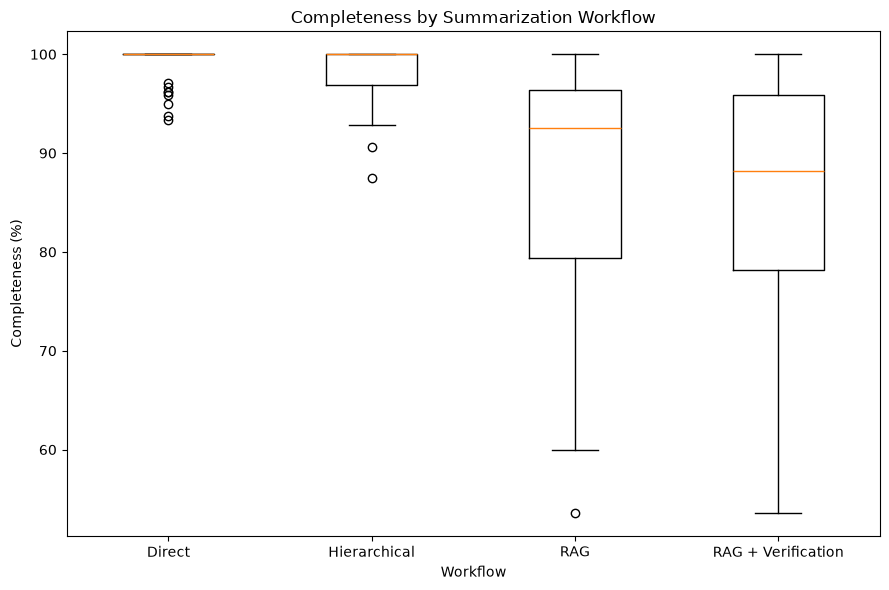

In [52]:
# ---------------------------------------------------------
# Plot completeness score distributions
# ---------------------------------------------------------

import matplotlib.pyplot as plt

workflow_order = [
    "direct",
    "hierarchical",
    "rag",
    "rag_verification"
]

plot_data = [
    completeness_df.loc[
        completeness_df["workflow"] == workflow,
        "completeness_percentage"
    ]
    for workflow in workflow_order
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    plot_data,
    tick_labels=[
        "Direct",
        "Hierarchical",
        "RAG",
        "RAG + Verification"
    ]
)

plt.ylabel("Completeness (%)")
plt.xlabel("Workflow")
plt.title("Completeness by Summarization Workflow")

plt.tight_layout()
plt.show()

In [53]:
# ---------------------------------------------------------
# Friedman test for completeness
# ---------------------------------------------------------
# The same 50 patients are evaluated under all four
# workflows, so the observations are paired.

from scipy.stats import friedmanchisquare


# Create one row per patient and one column per workflow.
completeness_pivot = completeness_df.pivot(
    index="person_id",
    columns="workflow",
    values="completeness_percentage"
)


# Keep workflow order explicit.
completeness_pivot = completeness_pivot[
    [
        "direct",
        "hierarchical",
        "rag",
        "rag_verification"
    ]
]


print("Patients:", len(completeness_pivot))
print(
    "Missing values:",
    completeness_pivot.isna().sum().sum()
)


friedman_result = friedmanchisquare(
    completeness_pivot["direct"],
    completeness_pivot["hierarchical"],
    completeness_pivot["rag"],
    completeness_pivot["rag_verification"]
)


print(
    "Friedman statistic:",
    round(friedman_result.statistic, 4)
)

print(
    "p-value:",
    friedman_result.pvalue
)

Patients: 50
Missing values: 0
Friedman statistic: 97.7298
p-value: 4.7816040487534075e-21


In [3]:
# ---------------------------------------------------------
# RECOVERY AFTER KERNEL RESTART
# ---------------------------------------------------------
# No LLM/API calls are made in this cell.
# It reloads the already-saved completeness results and
# reconstructs the variables needed for statistical analysis.


# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent.parent

RESULTS_DIR = (
    PROJECT_ROOT / "data" / "results"
)

EVALUATION_DIR = (
    RESULTS_DIR / "evaluation"
)

COMPLETENESS_RESULTS_PATH = (
    EVALUATION_DIR / "completeness_results.json"
)


# ---------------------------------------------------------
# Reload saved completeness results
# ---------------------------------------------------------

with open(COMPLETENESS_RESULTS_PATH, "r") as f:
    completeness_results = json.load(f)

print(
    "Patients loaded:",
    len(completeness_results)
)


# ---------------------------------------------------------
# Recalculate patient-level completeness percentages
# ---------------------------------------------------------

workflow_names = [
    "direct",
    "hierarchical",
    "rag",
    "rag_verification"
]

completeness_rows = []


for person_id, patient_result in completeness_results.items():

    scores = patient_result["scores"]

    number_of_facts = len(scores)
    maximum_score = 2 * number_of_facts

    for workflow in workflow_names:

        total_score = sum(
            fact_score[workflow]
            for fact_score in scores
        )

        completeness_percentage = (
            total_score / maximum_score
        ) * 100

        completeness_rows.append({
            "person_id": person_id,
            "workflow": workflow,
            "reference_fact_count": number_of_facts,
            "total_score": total_score,
            "maximum_score": maximum_score,
            "completeness_percentage":
                completeness_percentage
        })


completeness_df = pd.DataFrame(
    completeness_rows
)


# ---------------------------------------------------------
# Recreate paired patient × workflow table
# ---------------------------------------------------------

completeness_pivot = completeness_df.pivot(
    index="person_id",
    columns="workflow",
    values="completeness_percentage"
)

completeness_pivot = completeness_pivot[
    [
        "direct",
        "hierarchical",
        "rag",
        "rag_verification"
    ]
]


# ---------------------------------------------------------
# Validate recovery
# ---------------------------------------------------------

print(
    "Completeness scores:",
    len(completeness_df)
)

print(
    "Patients in pivot:",
    len(completeness_pivot)
)

print(
    "Missing values:",
    completeness_pivot.isna().sum().sum()
)

Patients loaded: 50
Completeness scores: 200
Patients in pivot: 50
Missing values: 0


In [4]:
# ---------------------------------------------------------
# Pairwise post-hoc tests for completeness
# ---------------------------------------------------------
# Friedman tells us that at least one workflow differs.
# These paired Wilcoxon tests identify WHICH workflow
# pairs differ.
#
# Holm correction adjusts the p-values because we are
# performing 6 pairwise comparisons.

from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


workflow_order = [
    "direct",
    "hierarchical",
    "rag",
    "rag_verification"
]

pairwise_results = []


# ---------------------------------------------------------
# Run all 6 paired comparisons
# ---------------------------------------------------------

for workflow_a, workflow_b in combinations(
    workflow_order,
    2
):

    scores_a = completeness_pivot[workflow_a]
    scores_b = completeness_pivot[workflow_b]

    # Paired Wilcoxon signed-rank test.
    result = wilcoxon(
        scores_a,
        scores_b,
        zero_method="pratt"
    )

    pairwise_results.append({
        "workflow_a": workflow_a,
        "workflow_b": workflow_b,
        "statistic": result.statistic,
        "raw_p_value": result.pvalue
    })


pairwise_df = pd.DataFrame(pairwise_results)


# ---------------------------------------------------------
# Holm multiple-comparison correction
# ---------------------------------------------------------

reject, adjusted_p_values, _, _ = multipletests(
    pairwise_df["raw_p_value"],
    method="holm",
    alpha=0.05
)

pairwise_df["adjusted_p_value"] = adjusted_p_values
pairwise_df["significant"] = reject


# Make output easier to read.
pairwise_df["statistic"] = (
    pairwise_df["statistic"].round(4)
)

print("Pairwise completeness comparisons:\n")

display(pairwise_df)

Pairwise completeness comparisons:



,workflow_a,workflow_b,statistic,raw_p_value,adjusted_p_value,significant
0,direct,hierarchical,86.0,7.504288e-03,7.504288e-03,True
1,direct,rag,16.5,1.499068e-08,5.996271e-08,True
2,direct,rag_verification,12.5,4.258580e-09,2.555148e-08,True
3,hierarchical,rag,47.0,6.157964e-08,1.847389e-07,True
4,hierarchical,rag_verification,13.0,4.380182e-09,2.555148e-08,True
5,rag,rag_verification,0.0,6.987524e-05,1.397505e-04,True


In [6]:
# ---------------------------------------------------------
# Find patients where RAG completeness > Direct completeness
# ---------------------------------------------------------

rag_vs_direct = (
    completeness_pivot[
        ["direct", "rag"]
    ]
    .copy()
)

rag_vs_direct["difference"] = (
    rag_vs_direct["rag"]
    - rag_vs_direct["direct"]
)

# Patients where RAG scored higher than Direct.
rag_better = (
    rag_vs_direct[
        rag_vs_direct["difference"] > 0
    ]
    .sort_values(
        "difference",
        ascending=False
    )
)

print(
    "Patients where RAG > Direct:",
    len(rag_better)
)

display(rag_better)

Patients where RAG > Direct: 1


workflow,direct,rag,difference
person_id,,,
ebb1ca4c-f42f-41d8-adbc-1b08949036d1,96.153846,100.0,3.846154


In [8]:
# ---------------------------------------------------------
# Reload saved reference checklists after kernel restart
# ---------------------------------------------------------

CHECKLIST_PATH = (
    EVALUATION_DIR
    / "completeness_reference_checklists.json"
)

with open(CHECKLIST_PATH, "r") as f:
    reference_checklists = json.load(f)

print(
    "Reference checklists loaded:",
    len(reference_checklists)
)

Reference checklists loaded: 50


In [9]:
# ---------------------------------------------------------
# Inspect the patient where RAG outperformed Direct
# ---------------------------------------------------------

rag_better_person_id = (
    rag_better.index[0]
)

patient_scores = completeness_results[
    rag_better_person_id
]["scores"]

patient_facts = reference_checklists[
    rag_better_person_id
]["facts"]


comparison_rows = []

for fact, score in zip(
    patient_facts,
    patient_scores
):

    comparison_rows.append({
        "fact_id": fact["fact_id"],
        "reference_fact": fact["fact"],
        "direct_score": score["direct"],
        "rag_score": score["rag"],
        "difference": (
            score["rag"] - score["direct"]
        )
    })


rag_better_fact_df = pd.DataFrame(
    comparison_rows
)


# Show only facts where RAG received more credit.
rag_advantage_facts = (
    rag_better_fact_df[
        rag_better_fact_df["difference"] > 0
    ]
)

display(rag_advantage_facts)

,fact_id,reference_fact,direct_score,rag_score,difference
9,10,Postoperative analgesia included paracetamol a...,1,2,1


In [15]:
# ---------------------------------------------------------
# Reload the correct 50-patient Direct summaries
# ---------------------------------------------------------

DIRECT_PATH = (
    RESULTS_DIR
    / "direct"
    / "direct_summaries.json"
)

with open(DIRECT_PATH, "r") as f:
    direct_results = json.load(f)

workflow_summaries["direct"] = {
    person_id: data["summary"]
    for person_id, data in direct_results.items()
}

print("Direct summaries:", len(workflow_summaries["direct"]))
print(
    "Target patient present:",
    "ebb1ca4c-f42f-41d8-adbc-1b08949036d1"
    in workflow_summaries["direct"]
)

Direct summaries: 50
Target patient present: True


In [16]:
# ---------------------------------------------------------
# Qualitative inspection of the one RAG > Direct case
# ---------------------------------------------------------

person_id = "ebb1ca4c-f42f-41d8-adbc-1b08949036d1"

# Reference fact that produced the difference.
fact_10 = reference_checklists[person_id]["facts"][9]

print("REFERENCE FACT:")
print(fact_10["fact"])

print("\nDIRECT SUMMARY:")
print(workflow_summaries["direct"][person_id])

print("\nRAG SUMMARY:")
print(workflow_summaries["rag"][person_id])

REFERENCE FACT:
Postoperative analgesia included paracetamol and ibuprofen, with paracetamol later reduced to PRN and ibuprofen continued.

DIRECT SUMMARY:
Victoria Edith Adams, an 8-year-old girl, was assessed preoperatively for a two-year history of recurrent left knee pain, gait abnormality, and left distal femoral valgus/angular deformity with growth plate arrest. Previous radiographs showed the deformity without lytic lesions. Examination demonstrated an antalgic gait, mild swelling and medial joint-line tenderness with flexion discomfort. Preoperative blood tests showed iron-deficiency anaemia (Hb 10.9 g/dL, low MCV), with normal WCC, platelets, renal, liver, and coagulation profiles. Oral ferrous sulfate 125 mg daily was commenced, and consent was obtained for hemiepiphysiodesis.

Repeat preoperative testing on 04/01/26 showed improved haemoglobin of 12.3 g/dL, with otherwise normal blood results. She was admitted electively on 06/01/26 and underwent left distal femoral lateral 